# Imports and pre-processing

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb

In [2]:
df_train = pd.read_csv('data/X_train.csv', sep=';', header=0)
df_test = pd.read_csv('data/X_test.csv', sep=';', header=0)

df_train["split"] = "train"
df_test["split"] = "test"

df = pd.concat([df_train, df_test], ignore_index=True)

In [3]:
df = df[["id", "aspect_ratio", "channel", "video_duration", "release_year", "split"]]
df.head()

,id,aspect_ratio,channel,video_duration,release_year,split
0,7602656035161050390,0.56,Davos Klosters,13,2026,train
1,7590718903144287510,0.56,Davos Klosters,12,2026,train
2,7571821778746592534,0.56,Davos Klosters,13,2025,train
3,7569927329154190614,0.56,Davos Klosters,7,2025,train
4,7566270741134462230,0.56,Davos Klosters,8,2025,train


In [4]:
text_class_df = pd.read_csv("text_classification_results.csv")
text_class_df.head()

,surprise,suspense,curiosity,clickbait,gibberish,Text,id
0,0.9103,0.9030,0.9014,0.0624,0.0163,~~ ym oN eae * . Quiaressorti le matos ? &,6834420537545084166
1,0.3614,0.5454,0.5940,0.3079,0.0258,oh TikTok 2 @davosklosters,6855731886438763781
2,0.9318,0.9214,0.9360,0.4888,0.0625,"Tu viens, on s’envole ?",6860766213992090886
3,0.2842,0.4974,0.3471,0.2040,0.1185,Fa,6869621825035357441
4,0.7828,0.8069,0.9424,0.0583,0.0364,Have you ever danced in the mountains? @,6874890977631390978


In [5]:
text_class_df.sort_values(by="gibberish", ascending=False).head(10)

,surprise,suspense,curiosity,clickbait,gibberish,Text,id
428,0.6745,0.4948,0.4815,0.6396,0.9938,msg Vo ad Se — SO giFMegey,7440140885246971169
411,0.9528,0.0305,0.2714,0.7581,0.9934,£ Ce genre de moment ou rien d’autre ne compt...,7413269884840267040
388,0.4914,0.6265,0.5001,0.7362,0.9420,SSUMMER Kitzbihel,7369936386000031009
256,0.3611,0.2937,0.1717,0.8443,0.9376,This titer melss,7264519435086466336
545,0.9082,0.8930,0.6868,0.7703,0.9280,mherapie dans la poudreuse! Waattien de mieux,7575170897451945238
329,0.3258,0.4832,0.3833,0.7322,0.9087,Kitzbiihel,7324696131143847201
262,0.8039,0.9192,0.6985,0.9482,0.9014,Pov: toi et ton pote en route pour mettre le f...,7270891504346942753
289,0.5815,0.8848,0.3736,0.6727,0.8895,Wetting tor ine Skifseasombellike:,7294901504752782625
409,0.8271,0.4843,0.5655,0.6365,0.8859,T’es sur le télésiége le plus off pourquoi tu ...,7410359060681297184
156,0.7953,0.7203,0.7810,0.8229,0.8726,GAM YOU GUSEES WHERE,7193034087660031237


In [6]:
text_class_df.fillna(0, inplace=True)
text_class_df.drop(columns=["gibberish"], inplace=True)

In [7]:
text_class_df["hook_catchiness"] = text_class_df[["surprise", "suspense", "curiosity", "clickbait"]].mean(axis=1)
text_class_df.sort_values(by="hook_catchiness", ascending=False).head(10)

,surprise,suspense,curiosity,clickbait,Text,id,hook_catchiness
349,0.9617,0.9304,0.8498,0.9614,longue de France et tu fais ‘quejtomber,7335861253551787297,0.925825
90,0.9738,0.9454,0.9008,0.7974,"POV: Es tu primer dia,des de. ski y tus amigo...",7083526112558517510,0.904350
12,0.9294,0.9760,0.7986,0.8880,Ca croustille sous les chaussures @®,6894530886105042178,0.898000
480,0.9591,0.8870,0.8915,0.7533,ri Don’t know who needs to hear this = Nite ...,7489499424884821270,0.872725
312,0.9380,0.9454,0.9587,0.6382,« Tu penses qu’on meurt si on saute du télésié...,7312851563037330721,0.870075
262,0.8039,0.9192,0.6985,0.9482,Pov: toi et ton pote en route pour mettre le f...,7270891504346942753,0.842450
33,0.8950,0.9487,0.9666,0.5378,QUI VIENT SKIER ?,7026774067223055621,0.837025
403,0.8691,0.8038,0.7624,0.8694,Onne peut pas acheter le ~:,7400784701633416481,0.826175
80,0.8733,0.7949,0.8822,0.7531,a Nuestra cara cada vez que vemos a alguien e...,7080535307816291589,0.825875
2,0.9318,0.9214,0.9360,0.4888,"Tu viens, on s’envole ?",6860766213992090886,0.819500


In [8]:
df = df.merge(text_class_df[["id", "hook_catchiness"]], on="id", how="left")
df["hook_catchiness"] = df["hook_catchiness"].fillna(0)
df.head()

,id,aspect_ratio,channel,video_duration,release_year,split,hook_catchiness
0,7602656035161050390,0.56,Davos Klosters,13,2026,train,0.000000
1,7590718903144287510,0.56,Davos Klosters,12,2026,train,0.000000
2,7571821778746592534,0.56,Davos Klosters,13,2025,train,0.000000
3,7569927329154190614,0.56,Davos Klosters,7,2025,train,0.000000
4,7566270741134462230,0.56,Davos Klosters,8,2025,train,0.371125


In [9]:
vad_df = pd.read_csv("valence_arousal_results.csv")

vad_df["id"] = vad_df["id"].str.replace('VIDEO_', '', regex=False)
vad_df["id"] = vad_df["id"].astype(int)

vad_df.drop(columns=["dominance"], inplace=True)

In [10]:
df = df.merge(vad_df, on="id", how="left")
df.head()

,id,aspect_ratio,channel,video_duration,release_year,split,hook_catchiness,valence,arousal
0,7602656035161050390,0.56,Davos Klosters,13,2026,train,0.000000,0.555430,0.472668
1,7590718903144287510,0.56,Davos Klosters,12,2026,train,0.000000,0.280632,0.238745
2,7571821778746592534,0.56,Davos Klosters,13,2025,train,0.000000,0.471083,0.685336
3,7569927329154190614,0.56,Davos Klosters,7,2025,train,0.000000,0.294391,0.938662
4,7566270741134462230,0.56,Davos Klosters,8,2025,train,0.371125,0.543724,0.917663


In [11]:
tempo_ft_df = pd.read_csv("final_hook_features.csv")
tempo_ft_df.drop(columns=["filepath", "split"], inplace=True)

In [12]:
df = df.merge(tempo_ft_df, on="id", how="left")
df.head()

,id,aspect_ratio,channel,video_duration,release_year,split,hook_catchiness,valence,arousal,max_spike,avg_volatility,max_motion_spike,avg_overall_motion
0,7602656035161050390,0.56,Davos Klosters,13,2026,train,0.000000,0.555430,0.472668,6.204138,4.442986,132.394,5.629
1,7590718903144287510,0.56,Davos Klosters,12,2026,train,0.000000,0.280632,0.238745,69.816795,6.330782,192.246,3.378
2,7571821778746592534,0.56,Davos Klosters,13,2025,train,0.000000,0.471083,0.685336,29.082718,2.700911,2.309,1.078
3,7569927329154190614,0.56,Davos Klosters,7,2025,train,0.000000,0.294391,0.938662,1.286115,0.903864,2.314,1.030
4,7566270741134462230,0.56,Davos Klosters,8,2025,train,0.371125,0.543724,0.917663,17.086381,15.656680,2.314,1.087


In [13]:
channel_to_id = {channel: idx for idx, channel in enumerate(df["channel"].unique())}
id_to_channel = {idx: channel for channel, idx in channel_to_id.items()}

df["channel_id"] = df["channel"].map(channel_to_id)
df.drop(columns=["channel"], inplace=True)
df.head()

,id,aspect_ratio,video_duration,release_year,split,hook_catchiness,valence,arousal,max_spike,avg_volatility,max_motion_spike,avg_overall_motion,channel_id
0,7602656035161050390,0.56,13,2026,train,0.000000,0.555430,0.472668,6.204138,4.442986,132.394,5.629,0
1,7590718903144287510,0.56,12,2026,train,0.000000,0.280632,0.238745,69.816795,6.330782,192.246,3.378,0
2,7571821778746592534,0.56,13,2025,train,0.000000,0.471083,0.685336,29.082718,2.700911,2.309,1.078,0
3,7569927329154190614,0.56,7,2025,train,0.000000,0.294391,0.938662,1.286115,0.903864,2.314,1.030,0
4,7566270741134462230,0.56,8,2025,train,0.371125,0.543724,0.917663,17.086381,15.656680,2.314,1.087,0


In [14]:
bluebird_df = pd.read_csv("csv_features/bluebird_factor.csv")
df = df.merge(bluebird_df, left_on="id", right_on="video_id", how="left")

loop_df = pd.read_csv("csv_features/loopable_simple.csv", sep=';', header=0)
loop_df.drop(columns=["mae"], inplace=True)
df = df.merge(loop_df, on="id", how="left")

sync_df = pd.read_csv("csv_features/sync_score_ordered.csv", sep=';', header=0)
sync_df.drop(columns=["n_cuts", "n_beats"], inplace=True)
df = df.merge(sync_df, left_on="id", right_on="video_id", how="left")

df.head()

,id,aspect_ratio,video_duration,release_year,split,hook_catchiness,valence,arousal,max_spike,avg_volatility,max_motion_spike,avg_overall_motion,channel_id,video_id_x,bluebird_score,loopable,video_id_y,sync_score
0,7602656035161050390,0.56,13,2026,train,0.000000,0.555430,0.472668,6.204138,4.442986,132.394,5.629,0,7602656035161050390,0.237109,NaN,NaN,NaN
1,7590718903144287510,0.56,12,2026,train,0.000000,0.280632,0.238745,69.816795,6.330782,192.246,3.378,0,7590718903144287510,0.003781,NaN,NaN,NaN
2,7571821778746592534,0.56,13,2025,train,0.000000,0.471083,0.685336,29.082718,2.700911,2.309,1.078,0,7571821778746592534,0.389989,NaN,NaN,NaN
3,7569927329154190614,0.56,7,2025,train,0.000000,0.294391,0.938662,1.286115,0.903864,2.314,1.030,0,7569927329154190614,0.967741,NaN,NaN,NaN
4,7566270741134462230,0.56,8,2025,train,0.371125,0.543724,0.917663,17.086381,15.656680,2.314,1.087,0,7566270741134462230,0.307146,NaN,NaN,NaN


In [15]:
df.drop(columns=["video_id_x", "video_id_y"], inplace=True)
df = df.fillna(0)
df.head()

,id,aspect_ratio,video_duration,release_year,split,hook_catchiness,valence,arousal,max_spike,avg_volatility,max_motion_spike,avg_overall_motion,channel_id,bluebird_score,loopable,sync_score
0,7602656035161050390,0.56,13,2026,train,0.000000,0.555430,0.472668,6.204138,4.442986,132.394,5.629,0,0.237109,0.0,0.0
1,7590718903144287510,0.56,12,2026,train,0.000000,0.280632,0.238745,69.816795,6.330782,192.246,3.378,0,0.003781,0.0,0.0
2,7571821778746592534,0.56,13,2025,train,0.000000,0.471083,0.685336,29.082718,2.700911,2.309,1.078,0,0.389989,0.0,0.0
3,7569927329154190614,0.56,7,2025,train,0.000000,0.294391,0.938662,1.286115,0.903864,2.314,1.030,0,0.967741,0.0,0.0
4,7566270741134462230,0.56,8,2025,train,0.371125,0.543724,0.917663,17.086381,15.656680,2.314,1.087,0,0.307146,0.0,0.0


In [16]:
train_df = df[df["split"] == "train"]

target_df = pd.read_csv("data/y_train.csv", sep=';', header=0)
train_df = train_df.merge(target_df, left_on="id", right_on="ID", how="left")

train_df.drop(columns=["split", "ID", "id"], inplace=True)
train_df.head()

,aspect_ratio,video_duration,release_year,hook_catchiness,valence,arousal,max_spike,avg_volatility,max_motion_spike,avg_overall_motion,channel_id,bluebird_score,loopable,sync_score,popularity
0,0.56,13,2026,0.000000,0.555430,0.472668,6.204138,4.442986,132.394,5.629,0,0.237109,0.0,0.0,8.603777
1,0.56,12,2026,0.000000,0.280632,0.238745,69.816795,6.330782,192.246,3.378,0,0.003781,0.0,0.0,8.537734
2,0.56,13,2025,0.000000,0.471083,0.685336,29.082718,2.700911,2.309,1.078,0,0.389989,0.0,0.0,11.208495
3,0.56,7,2025,0.000000,0.294391,0.938662,1.286115,0.903864,2.314,1.030,0,0.967741,0.0,0.0,11.982352
4,0.56,8,2025,0.371125,0.543724,0.917663,17.086381,15.656680,2.314,1.087,0,0.307146,0.0,0.0,8.678487


# Training

In [26]:
train_df.drop(columns=["channel_id", "loopable", "sync_score"], inplace=True)
X = train_df.drop(columns=['popularity'])
y = train_df['popularity']

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # The standard loss function for regression
    n_estimators=100,             # Number of gradient boosted trees
    max_depth=6,                  # Maximum tree depth for base learners
    learning_rate=0.3,            # Boosting learning rate (also known as eta)
    booster='gbtree',             # The underlying booster model
    subsample=1.0,                # Subsample ratio of the training instances
    colsample_bytree=1.0,         # Subsample ratio of columns when constructing each tree
    gamma=0,                      # Minimum loss reduction required to make a further partition
    min_child_weight=1,           # Minimum sum of instance weight (hessian) needed in a child
    reg_alpha=0,                  # L1 regularization term on weights
    reg_lambda=1,                 # L2 regularization term on weights
    random_state=42               
)

# 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Training the XGBoost model with 5-fold cross-validation...")
cv_scores = cross_val_score(xgb_model, X, y, cv=kfold, scoring='neg_mean_squared_error')
print(f"CV Scores (MSE): {-cv_scores}")
print(f"Mean CV Score: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Training the XGBoost model with 5-fold cross-validation...
CV Scores (MSE): [2.98123921 3.06991174 3.43293675 3.33488854 2.67831529]
Mean CV Score: 3.0995 (+/- 0.2679)


In [27]:
# Train final model on full dataset
print("Training final model on full dataset...")
xgb_model.fit(X, y)
print("Training complete!")

Training final model on full dataset...
Training complete!


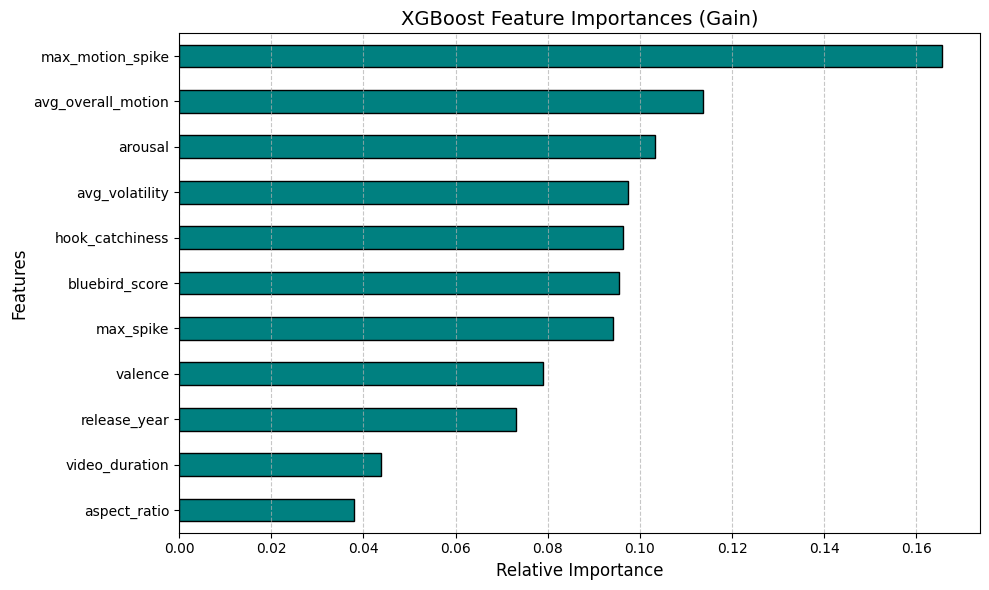

In [28]:
# Use the final model's feature importances
importances = xgb_model.feature_importances_
feature_names = X.columns

# Create a pandas Series, sort it, and plot it
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh', color='teal', edgecolor='black')

plt.title("XGBoost Feature Importances (Gain)", fontsize=14)
plt.xlabel("Relative Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()